# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/helnagar123/flyrank-ml-internship/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

# 0. Set Up

In [1]:
!pip -q install datasets huggingface_hub duckdb scikit-learn

import os
import duckdb
import warnings
import numpy as np
import pandas as pd

from datasets import load_dataset
from huggingface_hub import login
from google.colab import userdata

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)

HF_TOKEN = userdata.get("HF_TOKEN")
login(token=HF_TOKEN)

print("Environment ready.")

Environment ready.


In [2]:
content = load_dataset(
    "FlyRank/internship-warehouse",
    "dim_content",
    split="train"
)

performance = load_dataset(
    "FlyRank/internship-warehouse",
    "fact_content_daily_performance",
    split="train"
)

con = duckdb.connect()

con.register("dim_content", content.data.table)
con.register("daily_perf", performance.data.table)

display(
    con.sql("""
        SELECT COUNT(*) AS rows
        FROM dim_content
    """).df()
)

display(
    con.sql("""
        SELECT COUNT(*) AS rows
        FROM daily_perf
    """).df()
)

display(
    con.sql("""
        SELECT
            MIN(report_date) AS first_date,
            MAX(report_date) AS last_date
        FROM daily_perf
    """).df()
)

README.md:   0%|          | 0.00/3.04k [00:00<?, ?B/s]

dim_content.parquet: reconstructing file:   0%|          |  0.00B / 19.6MB            

dim_content.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/519606 [00:00<?, ? examples/s]

Resolving data files:   0%|          | 0/18 [00:00<?, ?it/s]

...

,rows
0,519606


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,rows
0,78835655


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,first_date,last_date
0,2025-01-27,2026-06-30


## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

In [10]:
con.sql("""
CREATE OR REPLACE VIEW refresh_features AS
SELECT
    p.report_date,
    c.client_hash_id,
    c.content_hash_id,
    c.content_created_date,
    c.content_updated_date,
    c.last_optimized_date,
    c.search_volume,
    c.backlinks,
    c.word_count,

    p.gsc_impressions,
    p.gsc_clicks,
    p.gsc_avg_position,

    CASE
        WHEN p.gsc_impressions > 0
        THEN 100.0 * p.gsc_clicks / p.gsc_impressions
        ELSE NULL
    END AS ctr,

    DATE_DIFF(
        'day',
        c.content_created_date,
        p.report_date
    ) AS content_age_days

FROM daily_perf p

JOIN dim_content c
    USING(content_hash_id)

WHERE
    p.gsc_data_available = TRUE
    AND c.is_published = TRUE
    AND c.is_deleted = FALSE
    AND c.content_created_date <= p.report_date
""")

print("refresh_features view created successfully.")

display(
    con.sql("""
        SELECT
            report_date,
            content_hash_id,
            content_created_date,
            content_updated_date,
            content_age_days,
            gsc_impressions,
            gsc_clicks,
            ctr
        FROM refresh_features
        LIMIT 5
    """).df()
)

display(
    con.sql("""
        SELECT
            MIN(content_age_days) AS min_age,
            MAX(content_age_days) AS max_age,
            COUNT(*) AS total_rows,
            SUM(
                CASE
                    WHEN content_age_days < 0 THEN 1
                    ELSE 0
                END
            ) AS negative_age_rows
        FROM refresh_features
    """).df()
)

refresh_features view created successfully.


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,report_date,content_hash_id,content_created_date,content_updated_date,content_age_days,gsc_impressions,gsc_clicks,ctr
0,2025-01-27,content_3b70a18ea133b2bb,2025-01-08,2026-05-18,19,30,0,0.0
1,2025-01-27,content_fe8e8155ce1d47a2,2025-01-08,2026-05-20,19,5,0,0.0
2,2025-01-27,content_b4462a1b90640058,2025-01-08,2026-05-18,19,1,0,0.0
3,2025-01-27,content_c899aef92518c714,2025-01-08,2026-05-18,19,6,0,0.0
4,2025-01-27,content_c7c1d2e68d9d0964,2025-01-08,2026-05-18,19,5,0,0.0


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,min_age,max_age,total_rows,negative_age_rows
0,0,585,28775297,0.0


In [11]:
feature_table = con.sql("""
SELECT
    content_hash_id,

    AVG(content_age_days) AS content_age_days,
    AVG(gsc_impressions) AS impressions,
    AVG(gsc_clicks) AS clicks,
    AVG(ctr) AS ctr,
    AVG(gsc_avg_position) AS position,

    MAX(search_volume) AS search_volume,
    MAX(backlinks) AS backlinks,
    MAX(word_count) AS word_count

FROM refresh_features

GROUP BY content_hash_id
""").df()

print("Feature table shape:", feature_table.shape)

display(feature_table.head())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Feature table shape: (292912, 9)


,content_hash_id,content_age_days,impressions,clicks,ctr,position,search_volume,backlinks,word_count
0,content_63a7896d96ce4d2d,276.027397,18.131115,0.142857,0.608232,32.144240,0,0,<NA>
1,content_ebe765f2af3f6214,278.500000,28.884615,0.100000,0.344072,6.352489,0,0,2716
2,content_2ff8034b464a2c95,274.794457,8.249423,0.034642,0.408782,42.976847,0,0,<NA>
3,content_3bd9016aab5d0aef,207.277612,5.465672,0.005970,0.129353,32.308728,0,0,<NA>
4,content_dc40416a3cf75e56,276.578641,55.763107,0.289320,0.500335,5.423530,0,0,2434


In [12]:
feature_table = feature_table.copy()

numeric_cols = [
    "content_age_days",
    "impressions",
    "clicks",
    "ctr",
    "position",
    "search_volume",
    "backlinks",
    "word_count",
]

for col in numeric_cols:
    feature_table[col] = pd.to_numeric(
        feature_table[col],
        errors="coerce"
    )

eligible = feature_table[
    feature_table["impressions"].notna()
    & (feature_table["impressions"] >= 20)
].copy()

print("Total content rows:", len(feature_table))
print("Eligible content rows:", len(eligible))
print(
    "Eligibility rate:",
    round(100 * len(eligible) / len(feature_table), 2),
    "%"
)

display(
    eligible[
        [
            "content_hash_id",
            "content_age_days",
            "impressions",
            "clicks",
            "ctr",
            "position",
            "search_volume",
            "backlinks",
            "word_count",
        ]
    ].head()
)

Total content rows: 292912
Eligible content rows: 71667
Eligibility rate: 24.47 %


,content_hash_id,content_age_days,impressions,clicks,ctr,position,search_volume,backlinks,word_count
1,content_ebe765f2af3f6214,278.500000,28.884615,0.100000,0.344072,6.352489,0,0,2716
4,content_dc40416a3cf75e56,276.578641,55.763107,0.289320,0.500335,5.423530,0,0,2434
5,content_6ac70228aa040ad2,241.803241,21.194444,0.050926,0.228579,28.380567,0,0,<NA>
6,content_f94fe855380e150f,260.747917,123.514583,1.375000,0.839841,7.356325,0,0,2240
9,content_a21d564ed74b1065,306.580645,25.320276,0.023041,0.268016,42.767961,0,0,<NA>


In [13]:
# Week-4 transparent baseline scoring

feature_table = eligible.copy()

# Normalize the four baseline signals to [0, 1]
for col in [
    "content_age_days",
    "impressions",
    "ctr",
    "position",
]:
    max_value = feature_table[col].max()

    feature_table[f"{col}_score"] = (
        feature_table[col] / max_value
        if max_value and not pd.isna(max_value)
        else 0.0
    )

# Higher CTR should reduce review priority
feature_table["ctr_score"] = 1 - feature_table["ctr_score"]

# Better position (smaller number) should increase priority
feature_table["position_score"] = 1 - feature_table["position_score"]

# Transparent Week-4 baseline
feature_table["baseline_score"] = (
    0.30 * feature_table["content_age_days_score"]
    + 0.30 * feature_table["ctr_score"]
    + 0.30 * feature_table["impressions_score"]
    + 0.10 * feature_table["position_score"]
)

print(f"Eligible pages scored: {len(feature_table):,}")

display(
    feature_table[
        [
            "content_hash_id",
            "content_age_days",
            "impressions",
            "ctr",
            "position",
            "content_age_days_score",
            "ctr_score",
            "impressions_score",
            "position_score",
            "baseline_score",
        ]
    ]
    .sort_values("baseline_score", ascending=False)
    .head(10)
)

Eligible pages scored: 71,667


,content_hash_id,content_age_days,impressions,ctr,position,content_age_days_score,ctr_score,impressions_score,position_score,baseline_score
190754,content_eadb33b5df496f4a,352.50885,12843.433628,1.018749,2.636037,0.679863,0.924901,1.000000,0.984786,0.879908
188986,content_963de14b1f58978f,444.50885,5025.464602,0.205337,4.935717,0.857298,0.984863,0.391287,0.971514,0.767186
42212,content_77276ad7a26f4905,444.50885,3582.508850,0.183195,5.662092,0.857298,0.986495,0.278937,0.967322,0.733551
44105,content_545bb6cc7081ded3,352.50885,5211.053097,0.401292,3.071687,0.679863,0.970418,0.405737,0.982272,0.715032
189971,content_ec2e0346994fb5a5,411.50885,3615.008850,0.475079,3.149019,0.793653,0.964978,0.281467,0.981826,0.710212
188996,content_f86f77b3ebdc05ee,444.50885,2654.526549,0.399847,4.473658,0.857298,0.970524,0.206684,0.974181,0.707770
42100,content_1e921148b5fee86a,444.50885,2203.942478,0.168956,5.473589,0.857298,0.987545,0.171601,0.968410,0.701774
190568,content_21309e9a83c83653,352.50885,4353.367257,0.195818,4.901104,0.679863,0.985565,0.338957,0.971714,0.698487
219609,content_d2eb49b1f5f3fa34,511.50000,287.552239,0.038469,10.927891,0.986500,0.997164,0.022389,0.936931,0.695509
73081,content_98648444f3cc6e80,511.50000,98.895522,0.002734,9.321601,0.986500,0.999798,0.007700,0.946202,0.692820


In [14]:
def get_reason(row):
    # 1. Very old + visible + weak CTR
    if (
        row["content_age_days"] >= 365
        and row["ctr"] < 1
        and row["impressions"] >= 100
    ):
        return "STALE_LOW_CTR"

    # 2. Mature + visible
    if (
        row["content_age_days"] >= 270
        and row["impressions"] >= 100
    ):
        return "DECAY_RISK_VISIBLE"

    # 3. High visibility + weak CTR
    if (
        row["impressions"] >= 1000
        and row["ctr"] < 2
    ):
        return "HIGH_IMPRESSIONS_LOW_CTR"

    # 4. Page-one position + weak CTR
    if (
        row["position"] <= 10
        and row["ctr"] < 2
    ):
        return "PAGE_ONE_CLICK_CAPTURE"

    # 5. Striking distance
    if (
        11 <= row["position"] <= 20
        and row["impressions"] >= 100
    ):
        return "STRIKING_DISTANCE"

    # 6. Low measurable demand
    if row["impressions"] < 100:
        return "LOW_VOLUME_MONITOR"

    # 7. Everything else
    return "GENERAL_REVIEW"


feature_table["reason_code"] = feature_table.apply(
    get_reason,
    axis=1
)


def map_action(row):
    reason = row["reason_code"]

    if reason in {
        "STALE_LOW_CTR",
        "DECAY_RISK_VISIBLE",
    }:
        return "REFRESH_CONTENT"

    if reason == "HIGH_IMPRESSIONS_LOW_CTR":
        return "IMPROVE_SNIPPET"

    if reason in {
        "PAGE_ONE_CLICK_CAPTURE",
        "STRIKING_DISTANCE",
    }:
        return "SUPPORT_PAGE_ONE"

    if reason == "LOW_VOLUME_MONITOR":
        return "MONITOR"

    return "HOLD_FOR_REVIEW"


feature_table["action"] = feature_table.apply(
    map_action,
    axis=1
)


ranked = (
    feature_table
    .sort_values(
        ["baseline_score", "impressions"],
        ascending=[False, False]
    )
    .reset_index(drop=True)
)

ranked.insert(
    0,
    "queue_rank",
    np.arange(1, len(ranked) + 1)
)


display(
    ranked.head(20)[
        [
            "queue_rank",
            "content_hash_id",
            "action",
            "reason_code",
            "baseline_score",
            "content_age_days",
            "impressions",
            "ctr",
            "position",
        ]
    ]
)

,queue_rank,content_hash_id,action,reason_code,baseline_score,content_age_days,impressions,ctr,position
0,1,content_eadb33b5df496f4a,REFRESH_CONTENT,DECAY_RISK_VISIBLE,0.879908,352.508850,12843.433628,1.018749,2.636037
1,2,content_963de14b1f58978f,REFRESH_CONTENT,STALE_LOW_CTR,0.767186,444.508850,5025.464602,0.205337,4.935717
2,3,content_77276ad7a26f4905,REFRESH_CONTENT,STALE_LOW_CTR,0.733551,444.508850,3582.508850,0.183195,5.662092
3,4,content_545bb6cc7081ded3,REFRESH_CONTENT,DECAY_RISK_VISIBLE,0.715032,352.508850,5211.053097,0.401292,3.071687
4,5,content_ec2e0346994fb5a5,REFRESH_CONTENT,STALE_LOW_CTR,0.710212,411.508850,3615.008850,0.475079,3.149019
5,6,content_f86f77b3ebdc05ee,REFRESH_CONTENT,STALE_LOW_CTR,0.707770,444.508850,2654.526549,0.399847,4.473658
6,7,content_1e921148b5fee86a,REFRESH_CONTENT,STALE_LOW_CTR,0.701774,444.508850,2203.942478,0.168956,5.473589
7,8,content_21309e9a83c83653,REFRESH_CONTENT,DECAY_RISK_VISIBLE,0.698487,352.508850,4353.367257,0.195818,4.901104
8,9,content_d2eb49b1f5f3fa34,REFRESH_CONTENT,STALE_LOW_CTR,0.695509,511.500000,287.552239,0.038469,10.927891
9,10,content_98648444f3cc6e80,SUPPORT_PAGE_ONE,PAGE_ONE_CLICK_CAPTURE,0.692820,511.500000,98.895522,0.002734,9.321601


In [15]:
# Review confidence is a data-quality / evidence-coverage signal,
# not a probability that the recommended action is correct.

required_signals = [
    "impressions",
    "ctr",
    "position",
    "content_age_days",
]

ranked["signal_coverage"] = (
    ranked[required_signals]
    .notna()
    .mean(axis=1)
)

ranked["review_confidence"] = np.select(
    [
        ranked["signal_coverage"] == 1.0,
        ranked["signal_coverage"] >= 0.75,
    ],
    [
        "HIGH",
        "MEDIUM",
    ],
    default="LOW",
)

display(
    ranked.head(20)[
        [
            "queue_rank",
            "content_hash_id",
            "action",
            "reason_code",
            "baseline_score",
            "review_confidence",
            "content_age_days",
            "impressions",
            "ctr",
            "position",
        ]
    ]
)

,queue_rank,content_hash_id,action,reason_code,baseline_score,review_confidence,content_age_days,impressions,ctr,position
0,1,content_eadb33b5df496f4a,REFRESH_CONTENT,DECAY_RISK_VISIBLE,0.879908,HIGH,352.508850,12843.433628,1.018749,2.636037
1,2,content_963de14b1f58978f,REFRESH_CONTENT,STALE_LOW_CTR,0.767186,HIGH,444.508850,5025.464602,0.205337,4.935717
2,3,content_77276ad7a26f4905,REFRESH_CONTENT,STALE_LOW_CTR,0.733551,HIGH,444.508850,3582.508850,0.183195,5.662092
3,4,content_545bb6cc7081ded3,REFRESH_CONTENT,DECAY_RISK_VISIBLE,0.715032,HIGH,352.508850,5211.053097,0.401292,3.071687
4,5,content_ec2e0346994fb5a5,REFRESH_CONTENT,STALE_LOW_CTR,0.710212,HIGH,411.508850,3615.008850,0.475079,3.149019
5,6,content_f86f77b3ebdc05ee,REFRESH_CONTENT,STALE_LOW_CTR,0.707770,HIGH,444.508850,2654.526549,0.399847,4.473658
6,7,content_1e921148b5fee86a,REFRESH_CONTENT,STALE_LOW_CTR,0.701774,HIGH,444.508850,2203.942478,0.168956,5.473589
7,8,content_21309e9a83c83653,REFRESH_CONTENT,DECAY_RISK_VISIBLE,0.698487,HIGH,352.508850,4353.367257,0.195818,4.901104
8,9,content_d2eb49b1f5f3fa34,REFRESH_CONTENT,STALE_LOW_CTR,0.695509,HIGH,511.500000,287.552239,0.038469,10.927891
9,10,content_98648444f3cc6e80,SUPPORT_PAGE_ONE,PAGE_ONE_CLICK_CAPTURE,0.692820,HIGH,511.500000,98.895522,0.002734,9.321601


## 2. Intended use and limits



### Intended use

This action queue is a decision-support artifact for human content review.

Its purpose is to:
- prioritize content pages for review,
- surface pages with observable visibility, CTR, position, and age signals,
- attach a transparent reason code to each ranked item,
- suggest a review action that an editor or SEO practitioner can evaluate.

The queue is intentionally non-production. The baseline score orders pages; the reason code explains why a page was surfaced; the suggested action is a review recommendation.

### What the queue does not claim

The queue does not estimate causal impact.

A high baseline score does not mean that refreshing a page will increase traffic, clicks, or rankings. The observed signals are used for prioritization, not as proof that a particular intervention will produce a specific outcome.

The Week-5 supervised model is not used as the action engine because its evaluation was affected by target leakage. The transparent baseline is therefore retained as the safer and more auditable prioritization mechanism.

### Limits

The queue is limited by:
- the available warehouse fields and reporting window,
- the impressions eligibility floor,
- missing or incomplete content metadata,
- the aggregation of daily observations to content-level features,
- the use of current content metadata where historical snapshots are not available.

The `review_confidence` field represents signal coverage only. It is not a model probability or a guarantee that the recommended action is correct.

All recommended actions require human review before execution.

## 3. Human review + the no-go list



### Human review rules

Every ranked recommendation requires human review before any content change is made.

The reviewer should check:

1. **Search intent**
   - Confirm that the page still matches the intended query or topic.
   - Check for changes in user intent or SERP context.

2. **Current content quality**
   - Review factual accuracy, completeness, freshness, and usefulness.
   - Check whether the page already received a recent manual update.

3. **SERP and CTR context**
   - Inspect whether low CTR may be related to title, description, SERP features, or search intent rather than content quality alone.

4. **Ranking context**
   - Check the current ranking position and whether the page is close enough to page one for a targeted intervention to be worthwhile.

5. **Cannibalization and site context**
   - Check whether another page targets the same intent.
   - Review internal linking and competing URLs before making a change.

6. **Business value and effort**
   - Estimate the expected value of the intervention relative to the effort and risk required.
   - Prefer high-value, low-risk actions when evidence is similar.

7. **Evidence quality**
   - Confirm that the signals used for the recommendation are complete and plausible.
   - `review_confidence` describes signal coverage; it does not mean that the recommendation is guaranteed to work.

### No-go list

The action queue must not automatically:

- rewrite or publish content,
- delete or prune pages,
- merge URLs,
- change canonical URLs,
- create redirects,
- make backlink decisions,
- change site architecture,
- infer search intent from the score alone,
- guarantee traffic, click, or ranking improvements,
- treat the baseline score as a causal estimate,
- use the Week-5 leaked model output as an automated decision signal.

These decisions require explicit human review and, where appropriate, additional evidence outside the action queue.

### Human decision rule

The queue is a prioritization and review aid, not an autonomous content-management system.

The operational rule is:

**Score → Rank → Explain → Human Review → Decide → Measure**

No content action should be executed solely because a page received a high queue rank.

## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

In [16]:
# Lightweight monitoring snapshot for the action queue.
# These checks are descriptive and are not production monitoring.

action_counts = (
    ranked["action"]
    .value_counts()
    .rename_axis("action")
    .reset_index(name="count")
)

reason_counts = (
    ranked["reason_code"]
    .value_counts()
    .rename_axis("reason_code")
    .reset_index(name="count")
)

monitoring_summary = pd.DataFrame({
    "metric": [
        "total_ranked_pages",
        "refresh_content_pages",
        "improve_snippet_pages",
        "support_page_one_pages",
        "monitor_pages",
        "hold_for_review_pages",
        "high_review_confidence_rate",
    ],
    "value": [
        len(ranked),
        (ranked["action"] == "REFRESH_CONTENT").sum(),
        (ranked["action"] == "IMPROVE_SNIPPET").sum(),
        (ranked["action"] == "SUPPORT_PAGE_ONE").sum(),
        (ranked["action"] == "MONITOR").sum(),
        (ranked["action"] == "HOLD_FOR_REVIEW").sum(),
        (
            ranked["review_confidence"].eq("HIGH").mean()
        ),
    ],
})

display(monitoring_summary)

print("\nAction distribution:")
display(action_counts)

print("\nReason-code distribution:")
display(reason_counts)

,metric,value
0,total_ranked_pages,71667.0
1,refresh_content_pages,1469.0
2,improve_snippet_pages,620.0
3,support_page_one_pages,39267.0
4,monitor_pages,27123.0
5,hold_for_review_pages,3188.0
6,high_review_confidence_rate,1.0



Action distribution:


,action,count
0,SUPPORT_PAGE_ONE,39267
1,MONITOR,27123
2,HOLD_FOR_REVIEW,3188
3,REFRESH_CONTENT,1469
4,IMPROVE_SNIPPET,620



Reason-code distribution:


,reason_code,count
0,PAGE_ONE_CLICK_CAPTURE,35702
1,LOW_VOLUME_MONITOR,27123
2,STRIKING_DISTANCE,3565
3,GENERAL_REVIEW,3188
4,DECAY_RISK_VISIBLE,984
5,HIGH_IMPRESSIONS_LOW_CTR,620
6,STALE_LOW_CTR,485


### Monitoring and retrain triggers

This notebook establishes a lightweight monitoring baseline for the current action queue.

The current queue contains 71,667 eligible ranked pages. The largest action groups are `SUPPORT_PAGE_ONE` and `MONITOR`, so future queue runs should be compared with this distribution rather than interpreted in isolation.

Monitoring should track:

- changes in the eligible population size,
- changes in the distribution of recommended actions,
- changes in reason-code distribution,
- changes in impressions, CTR, and position,
- whether previously high-priority pages continue to show the same signals.

A material change in the eligible population or action/reason distribution should trigger a review of the queue logic and underlying data before recommendations are used.

### Post-action measurement

For pages that receive a human-approved action, outcomes should be reviewed after approximately 30, 60, and 90 days when sufficient data is available.

The review should compare post-action observations with the pre-action baseline.

These comparisons are observational. They should not be interpreted as proof that the content action caused the observed change without an appropriate experimental design.

### Retrain triggers

Retraining should not happen simply because a fixed amount of time has passed.

A retraining proposal should require:

1. a future-window outcome label,
2. a leakage-safe feature window,
3. temporal or grouped validation,
4. successful leakage checks,
5. comparison against the transparent baseline,
6. evidence that the new model improves the intended ranking metric,
7. human review of representative top-ranked examples.

Until those conditions are met, the transparent baseline remains the action engine.

### No automatic retraining

This notebook does not implement automatic retraining.

These are review triggers for future iterations, not production automation.

## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

In [17]:
# Export the ranked content action queue for downstream paper use.

queue_columns = [
    "queue_rank",
    "content_hash_id",
    "action",
    "reason_code",
    "baseline_score",
    "review_confidence",
    "content_age_days",
    "impressions",
    "clicks",
    "ctr",
    "position",
    "search_volume",
    "backlinks",
    "word_count",
]

action_queue = ranked[queue_columns].copy()

queue_path = "work/outputs/content_action_queue.csv"

action_queue.to_csv(
    queue_path,
    index=False
)

print(f"Action queue exported to: {queue_path}")
print(f"Rows exported: {len(action_queue):,}")

display(action_queue.head(10))

Action queue exported to: work/outputs/content_action_queue.csv
Rows exported: 71,667


,queue_rank,content_hash_id,action,reason_code,baseline_score,review_confidence,content_age_days,impressions,clicks,ctr,position,search_volume,backlinks,word_count
0,1,content_eadb33b5df496f4a,REFRESH_CONTENT,DECAY_RISK_VISIBLE,0.879908,HIGH,352.50885,12843.433628,109.500000,1.018749,2.636037,390,<NA>,2753
1,2,content_963de14b1f58978f,REFRESH_CONTENT,STALE_LOW_CTR,0.767186,HIGH,444.50885,5025.464602,13.575221,0.205337,4.935717,210,<NA>,2745
2,3,content_77276ad7a26f4905,REFRESH_CONTENT,STALE_LOW_CTR,0.733551,HIGH,444.50885,3582.508850,5.756637,0.183195,5.662092,1900,<NA>,2674
3,4,content_545bb6cc7081ded3,REFRESH_CONTENT,DECAY_RISK_VISIBLE,0.715032,HIGH,352.50885,5211.053097,22.929204,0.401292,3.071687,40,<NA>,2811
4,5,content_ec2e0346994fb5a5,REFRESH_CONTENT,STALE_LOW_CTR,0.710212,HIGH,411.50885,3615.008850,17.672566,0.475079,3.149019,0,0,2581
5,6,content_f86f77b3ebdc05ee,REFRESH_CONTENT,STALE_LOW_CTR,0.707770,HIGH,444.50885,2654.526549,11.429204,0.399847,4.473658,590,<NA>,1114
6,7,content_1e921148b5fee86a,REFRESH_CONTENT,STALE_LOW_CTR,0.701774,HIGH,444.50885,2203.942478,2.809735,0.168956,5.473589,<NA>,<NA>,3343
7,8,content_21309e9a83c83653,REFRESH_CONTENT,DECAY_RISK_VISIBLE,0.698487,HIGH,352.50885,4353.367257,7.933628,0.195818,4.901104,10,<NA>,1214
8,9,content_d2eb49b1f5f3fa34,REFRESH_CONTENT,STALE_LOW_CTR,0.695509,HIGH,511.50000,287.552239,0.014925,0.038469,10.927891,<NA>,<NA>,<NA>
9,10,content_98648444f3cc6e80,SUPPORT_PAGE_ONE,PAGE_ONE_CLICK_CAPTURE,0.692820,HIGH,511.50000,98.895522,0.007463,0.002734,9.321601,0,<NA>,<NA>


In [18]:
# Export a compact action summary for the paper.

action_summary = (
    ranked
    .groupby("action")
    .agg(
        page_count=("content_hash_id", "count"),
        mean_baseline_score=("baseline_score", "mean"),
        median_baseline_score=("baseline_score", "median"),
    )
    .reset_index()
    .sort_values("page_count", ascending=False)
)

summary_path = "work/outputs/content_action_summary.csv"

action_summary.to_csv(
    summary_path,
    index=False
)

print(f"Action summary exported to: {summary_path}")

display(action_summary)

Action summary exported to: work/outputs/content_action_summary.csv


,action,page_count,mean_baseline_score,median_baseline_score
4,SUPPORT_PAGE_ONE,39267,0.457807,0.450133
2,MONITOR,27123,0.457789,0.445605
0,HOLD_FOR_REVIEW,3188,0.448581,0.445098
3,REFRESH_CONTENT,1469,0.598495,0.595061
1,IMPROVE_SNIPPET,620,0.485968,0.479302


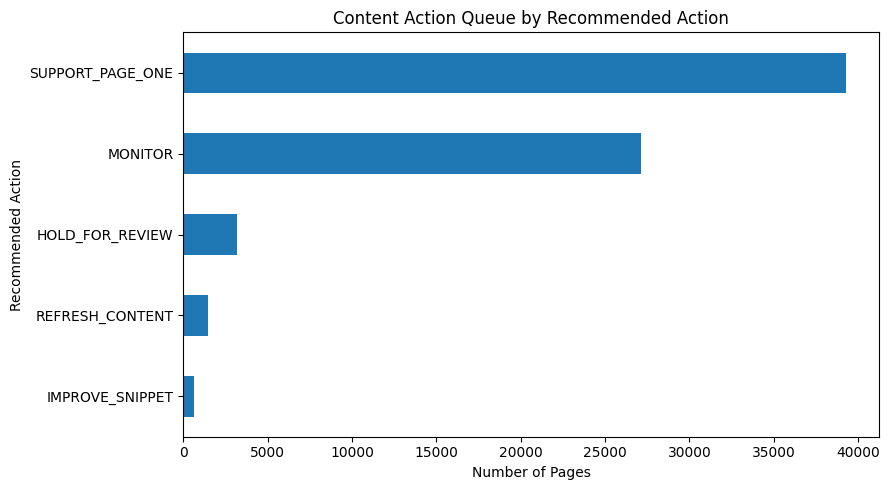

Figure exported to: work/figures/action_queue_by_action.png


In [19]:
import matplotlib.pyplot as plt

action_plot = (
    ranked["action"]
    .value_counts()
    .sort_values(ascending=True)
)

plt.figure(figsize=(9, 5))

action_plot.plot(kind="barh")

plt.title("Content Action Queue by Recommended Action")
plt.xlabel("Number of Pages")
plt.ylabel("Recommended Action")

plt.tight_layout()

figure_path = "work/figures/action_queue_by_action.png"

plt.savefig(
    figure_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print(f"Figure exported to: {figure_path}")

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.